# Testing features.py

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.features import build_features

apc_clean    = pd.read_csv('../data/processed/apc_clean.csv', sep=';', encoding='latin-1')
apc_features = build_features(apc_clean)

print(f"apc_clean:    {apc_clean.shape}")
print(f"apc_features: {apc_features.shape}")
print(f"New columns:  {apc_features.shape[1] - apc_clean.shape[1]}")

apc_clean:    (1598277, 17)
apc_features: (1598277, 39)
New columns:  22


## Trip overview
Reduce to one row per trip so we can study trip-level statistics without
the per-row repetition. Drop rows where `trip` is NaN (empty pismInformation)
and rows where `trip == 0` (placeholder for non-productive movements like
depot trips).

In [4]:
trips = (apc_features
         .dropna(subset=['trip'])
         .drop_duplicates(['vehicleCode', 'trip', 'date']))

print(f"Total trips: {len(trips):,}")
print()
print("Imbalance distribution:")
balanced = (trips['trip_imbalance'] == 0).sum()
ghost    = (trips['trip_imbalance'] >  0).sum()
missed   = (trips['trip_imbalance'] <  0).sum()

print(f"  Balanced (= 0):                          {balanced:>7,}  ({balanced/len(trips)*100:5.1f}%)")
print(f"  Ghost passengers (imbalance > 0):        {ghost:>7,}  ({ghost/len(trips)*100:5.1f}%)")
print(f"  Sensor missed boardings (imbalance < 0): {missed:>7,}  ({missed/len(trips)*100:5.1f}%)")

Total trips: 64,172

Imbalance distribution:
  Balanced (= 0):                           19,515  ( 30.4%)
  Ghost passengers (imbalance > 0):         24,417  ( 38.0%)
  Sensor missed boardings (imbalance < 0):  20,240  ( 31.5%)


## Plot 1: distribution of trip imbalance

Each trip should ideally have `trip_imbalance == 0` (everyone who boards
also alights). A peak at 0 confirms most trips are clean. Long tails on
either side show how often the sensor over- or under-counts. The shape
also reveals whether sensor errors are symmetric or biased.

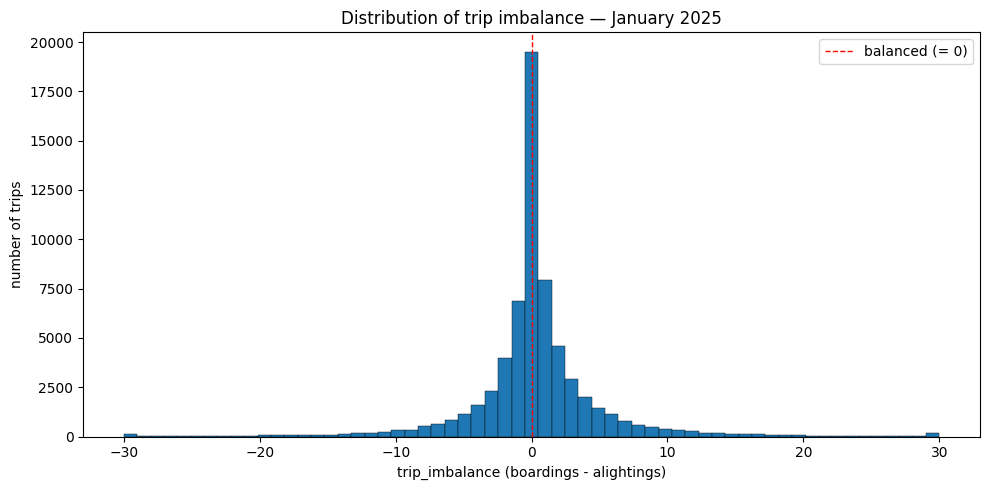

Trips with |imbalance| > 30 (clipped in plot): 291


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Clip the x-axis to a readable range. Extreme outliers (a few trips with
# imbalance > 50) compress the rest of the distribution if we don't.
clip_range = (-30, 30)
data = trips['trip_imbalance'].clip(*clip_range)

ax.hist(data, bins=61, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--', linewidth=1, label='balanced (= 0)')
ax.set_xlabel('trip_imbalance (boardings - alightings)')
ax.set_ylabel('number of trips')
ax.set_title('Distribution of trip imbalance — January 2025')
ax.legend()

plt.tight_layout()
plt.show()

# Print how many trips fall outside the plot range
outside = (trips['trip_imbalance'].abs() > 30).sum()
print(f"Trips with |imbalance| > 30 (clipped in plot): {outside:,}")

## Plot 2: distribution of trip_imbalance_z_score

`trip_imbalance` is hard to interpret on its own — an imbalance of 5 might
be normal on a long busy line and very abnormal on a short feeder line.
The z-score normalises imbalance against each line's own mean and standard
deviation. Values near 0 mean "typical for this line"; values beyond ±3
mean "this trip's imbalance is far outside what's normal for the line".

If the z-score calculation is reasonable, this distribution should look
roughly bell-shaped and centred at 0.

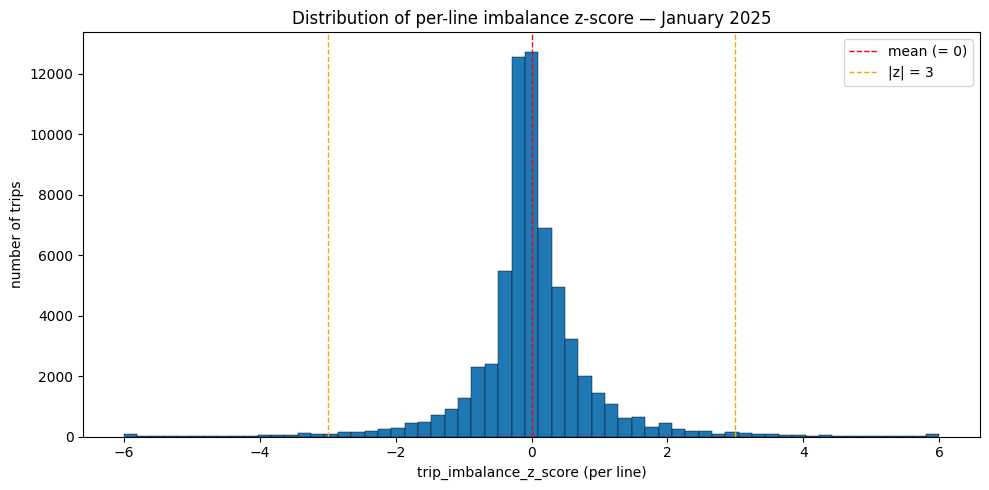

Trips with |z| > 3:  1,242  (1.94%)
Trips with |z| > 5:  271  (0.42%)
Trips outside plot range (|z| > 6): 137


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

clip_range = (-6, 6)
data = trips['trip_imbalance_z_score'].clip(*clip_range)

ax.hist(data, bins=61, edgecolor='black', linewidth=0.3)
ax.axvline(0,  color='red',    linestyle='--', linewidth=1, label='mean (= 0)')
ax.axvline(-3, color='orange', linestyle='--', linewidth=1, label='|z| = 3')
ax.axvline( 3, color='orange', linestyle='--', linewidth=1)
ax.set_xlabel('trip_imbalance_z_score (per line)')
ax.set_ylabel('number of trips')
ax.set_title('Distribution of per-line imbalance z-score — January 2025')
ax.legend()

plt.tight_layout()
plt.show()

# Summary
n_extreme = (trips['trip_imbalance_z_score'].abs() > 3).sum()
n_very    = (trips['trip_imbalance_z_score'].abs() > 5).sum()
n_clipped = (trips['trip_imbalance_z_score'].abs() > 6).sum()

print(f"Trips with |z| > 3:  {n_extreme:,}  ({n_extreme/len(trips)*100:.2f}%)")
print(f"Trips with |z| > 5:  {n_very:,}  ({n_very/len(trips)*100:.2f}%)")
print(f"Trips outside plot range (|z| > 6): {n_clipped:,}")

## Plot 3: distribution of trip_max_load

`trip_max_load` is the highest passenger count observed during a trip
(running cumulative load from the start). This tells us how full the
buses get and whether any trips show implausible passenger counts.

A typical city bus seats around 30 and has a crush capacity around 80.
Anything beyond ~100 is physically suspect and likely a sensor artefact.
This was the metric most affected by the trip-grouping bug — before the
fix, 59 trips showed max_load > 100 (cumulative across the month);
after the fix, only 1 remains.

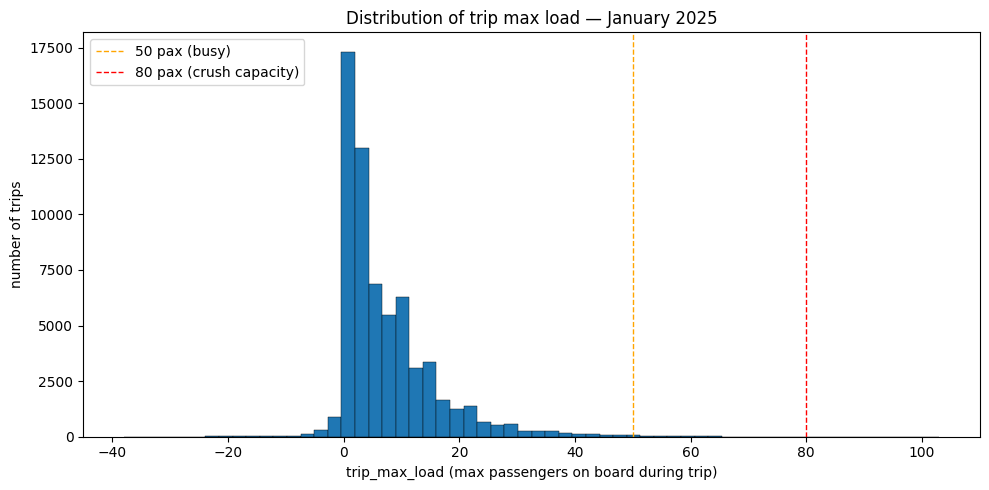

Trips with max_load >= 50:  128  (0.20%)
Trips with max_load >= 80:  2  (0.00%)
Trips with max_load > 100:  1
Highest max_load observed:  103
Lowest max_load observed:   -38  (negative => sensor artefact)


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# No clipping needed — max_load has a natural physical ceiling
data = trips['trip_max_load']

ax.hist(data, bins=60, edgecolor='black', linewidth=0.3)
ax.axvline(50,  color='orange', linestyle='--', linewidth=1, label='50 pax (busy)')
ax.axvline(80,  color='red',    linestyle='--', linewidth=1, label='80 pax (crush capacity)')
ax.set_xlabel('trip_max_load (max passengers on board during trip)')
ax.set_ylabel('number of trips')
ax.set_title('Distribution of trip max load — January 2025')
ax.legend()

plt.tight_layout()
plt.show()

# Summary
print(f"Trips with max_load >= 50:  {(trips['trip_max_load'] >= 50).sum():,}  "
      f"({(trips['trip_max_load'] >= 50).mean()*100:.2f}%)")
print(f"Trips with max_load >= 80:  {(trips['trip_max_load'] >= 80).sum():,}  "
      f"({(trips['trip_max_load'] >= 80).mean()*100:.2f}%)")
print(f"Trips with max_load > 100:  {(trips['trip_max_load'] >  100).sum():,}")
print(f"Highest max_load observed:  {trips['trip_max_load'].max():.0f}")
print(f"Lowest max_load observed:   {trips['trip_max_load'].min():.0f}  (negative => sensor artefact)")

## Plot 4: data quality signals per day

Aggregate two quality signals by date to see if they vary over time.
We look at trips with negative min_load (a physical impossibility,
indicating sensor undercount) and trips whose imbalance is more than
3 standard deviations from their line's average (statistical outliers).
Spikes on specific days could point to weather, holidays, or system
issues; flat lines mean issues are evenly spread over the month.

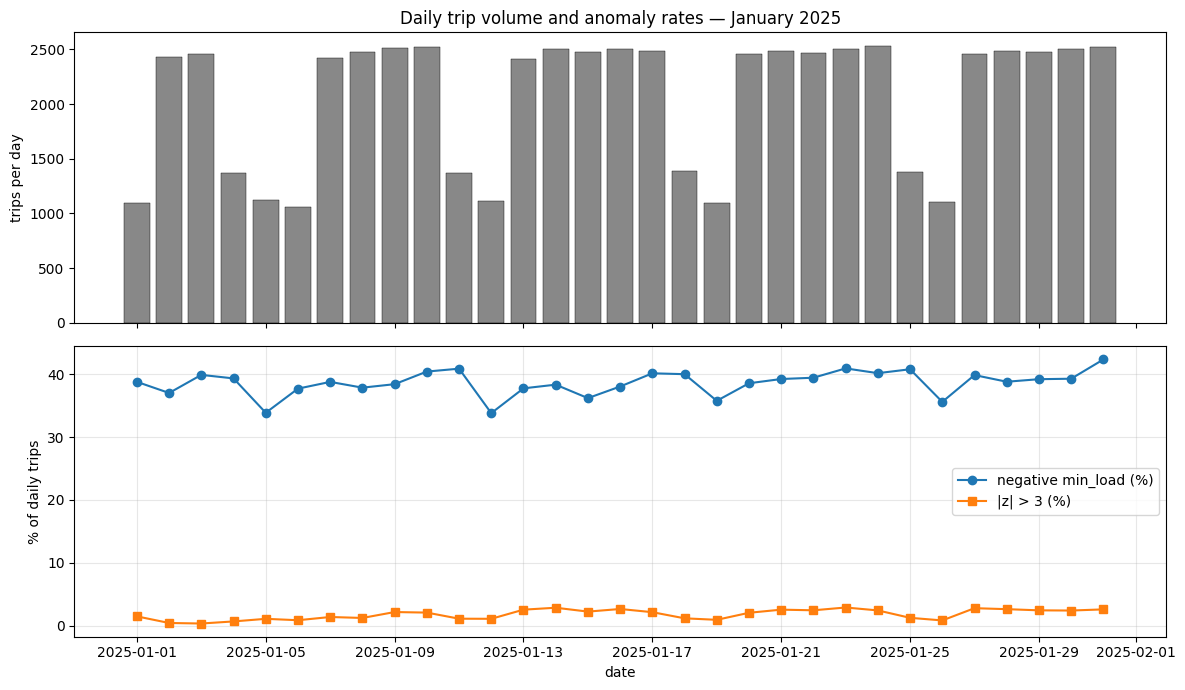

In [8]:
# Build per-day anomaly counts
trips['date'] = pd.to_datetime(trips['date'])

daily = trips.groupby('date').agg(
    n_trips        = ('trip', 'count'),
    n_neg_load     = ('trip_min_load',          lambda s: (s < 0).sum()),
    n_extreme_z    = ('trip_imbalance_z_score', lambda s: (s.abs() > 3).sum()),
).reset_index()

daily['pct_neg_load']  = daily['n_neg_load']  / daily['n_trips'] * 100
daily['pct_extreme_z'] = daily['n_extreme_z'] / daily['n_trips'] * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: total trips per day (context)
axes[0].bar(daily['date'], daily['n_trips'], color='#888', edgecolor='black', linewidth=0.3)
axes[0].set_ylabel('trips per day')
axes[0].set_title('Daily trip volume and anomaly rates — January 2025')

# Bottom: anomaly rates as % of trips
axes[1].plot(daily['date'], daily['pct_neg_load'],  marker='o', label='negative min_load (%)')
axes[1].plot(daily['date'], daily['pct_extreme_z'], marker='s', label='|z| > 3 (%)')
axes[1].set_ylabel('% of daily trips')
axes[1].set_xlabel('date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()